In [1]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


In [2]:
import seaborn as sns

In [3]:
import pandas as pd
df = pd.read_csv(path + "/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [6]:
for cols_unique_values in df.columns:
    print(cols_unique_values, df[cols_unique_values].unique())

gender ['female' 'male']
race/ethnicity ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch ['standard' 'free/reduced']
test preparation course ['none' 'completed']
math score [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
reading score [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
writing score [ 74  88  93  44  75  78  92 

In [7]:
male_passed_course_df = df[(df["gender"] == "male") & (df["test preparation course"] == "completed")]
female_passed_course_df = df[(df["gender"] == "female") & (df["test preparation course"] == "completed")]
print(len(male_passed_course_df))
print(len(female_passed_course_df))

174
184


In [8]:
male_passed_course_df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
8,male,group D,high school,free/reduced,completed,64,64,67
13,male,group A,some college,standard,completed,78,72,70
18,male,group C,master's degree,free/reduced,completed,46,42,46
24,male,group D,bachelor's degree,free/reduced,completed,74,71,80
35,male,group E,associate's degree,standard,completed,81,81,79


In [9]:
## Passing Criteria is score more than 50 in math. writing and reading and also preparation course completed

passed_students = df[(df["math score"] > 50) & (df["writing score"] > 50) & (df["reading score"] > 50) & (df["test preparation course"] == "completed")]
passed_students.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group C,some college,standard,completed,69,90,88
6,female,group B,some college,standard,completed,88,95,92
8,male,group D,high school,free/reduced,completed,64,64,67
13,male,group A,some college,standard,completed,78,72,70
21,female,group B,some college,free/reduced,completed,65,75,70


In [10]:
female = passed_students[passed_students["gender"] == "female"]
male = passed_students[passed_students["gender"] == "male"]

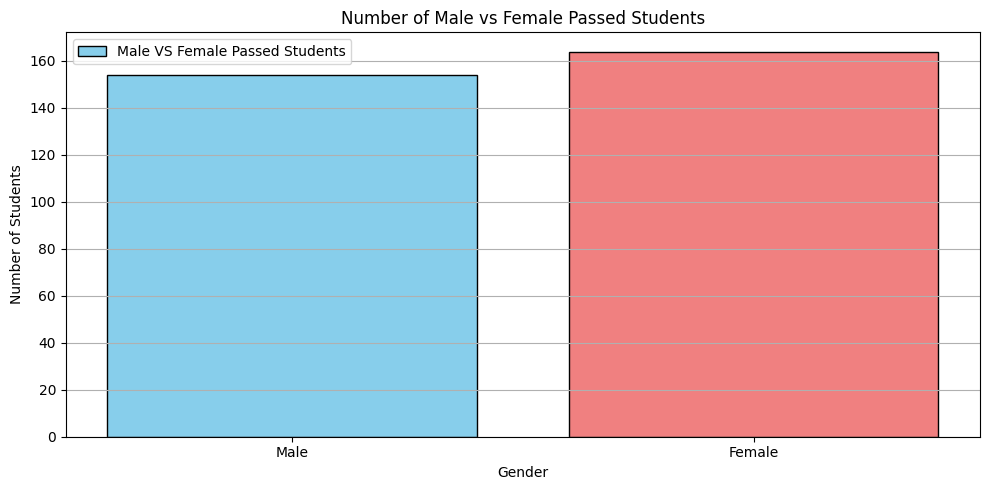

In [11]:
## Visuallizing the passed students by the help of Bar Graph using matplotlob

import matplotlib.pyplot as plt

male_count = len(male)
female_count = len(female)

plt.figure(figsize=(10, 5))
plt.bar(['Male', 'Female'], [male_count, female_count], color=["skyblue", "lightcoral"], edgecolor="black", label="Male VS Female Passed Students")
plt.grid(axis='y')
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.title("Number of Male vs Female Passed Students")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
students_parente_with_master_degree_or_bachelor = df[(df["parental level of education"] == "master's degree") | (df["parental level of education"] == "bachelor's degree")]
students_parente_with_master_degree_or_bachelor = df[(df["parental level of education"] == "some college") | (df["parental level of education"] == "associate's degree") | (df["parental level of education"] == "high school") | (df["parental level of education"] == "some high school")]
# students_parente_with_master_degree_or_bachelor.head(5)
students_parente_with_master_degree_or_bachelor.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group C,some college,standard,completed,69,90,88
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92


In [14]:
len(students_parente_with_master_degree_or_bachelor)
len(students_parente_with_master_degree_or_bachelor)

823

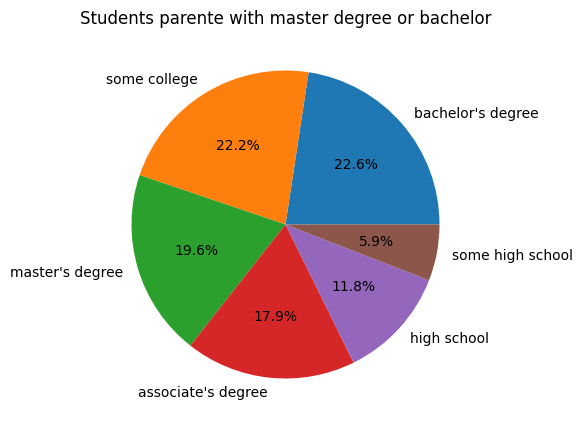

In [15]:
plt.figure(figsize=(10, 5))
plt.pie(df["parental level of education"].value_counts(), labels=df["parental level of education"].unique(), autopct="%1.1f%%")
plt.title("Students parente with master degree or bachelor")
plt.show()

In [16]:
topper_students = df[(df["math score"] > 90) & (df["writing score"] > 90) & (df["reading score"] > 90)]
topper_students.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
114,female,group E,bachelor's degree,standard,completed,99,100,100
149,male,group E,associate's degree,free/reduced,completed,100,100,93
165,female,group C,bachelor's degree,standard,completed,96,100,100
179,female,group D,some high school,standard,completed,97,100,100
451,female,group E,some college,standard,none,100,92,97


In [17]:
topper_students.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 114 to 979
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       23 non-null     object
 1   race/ethnicity               23 non-null     object
 2   parental level of education  23 non-null     object
 3   lunch                        23 non-null     object
 4   test preparation course      23 non-null     object
 5   math score                   23 non-null     int64 
 6   reading score                23 non-null     int64 
 7   writing score                23 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 1.6+ KB


In [18]:
topper_students.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


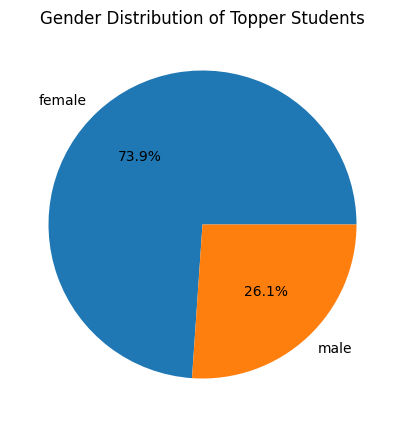

In [19]:
plt.figure(figsize=(10, 5))
gender_distribution = topper_students["gender"].value_counts()
plt.pie(gender_distribution, labels=gender_distribution.index, autopct="%1.1f%%")
plt.title("Gender Distribution of Topper Students")
plt.show()

In [20]:
## Topper Students Gender Distribution

len(topper_students)

23

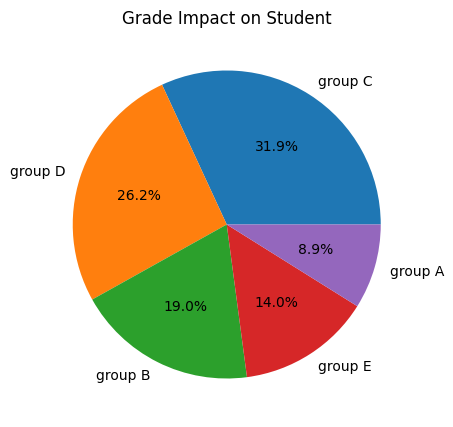

In [21]:
## Visuallising the Grade impact on the student, if student is pass or fail

grades = df["race/ethnicity"].value_counts()
plt.figure(figsize=(10, 5))
plt.pie(grades, labels=grades.index, autopct="%1.1f%%")
plt.title("Grade Impact on Student")
plt.show()

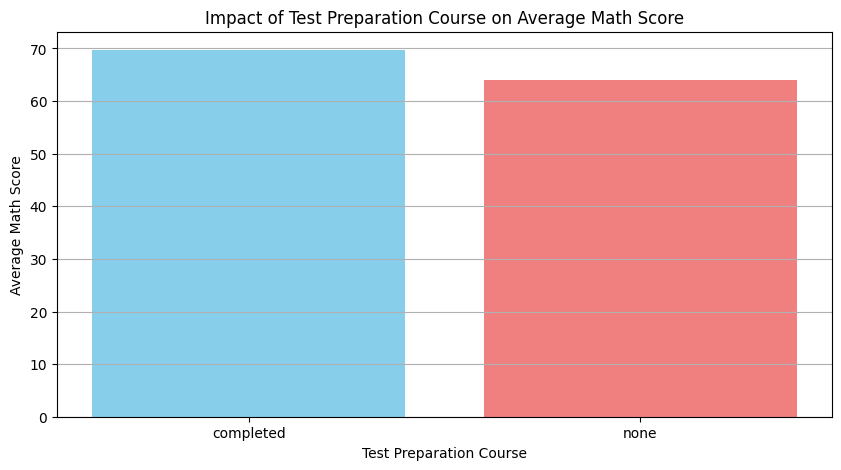

In [22]:
avg_math_score_by_prep = df.groupby("test preparation course")["math score"].mean()

plt.figure(figsize=(10, 5))
plt.bar(avg_math_score_by_prep.index, avg_math_score_by_prep.values, color=["skyblue", "lightcoral"])
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Math Score")
plt.title("Impact of Test Preparation Course on Average Math Score")
plt.grid(axis='y')
plt.show()

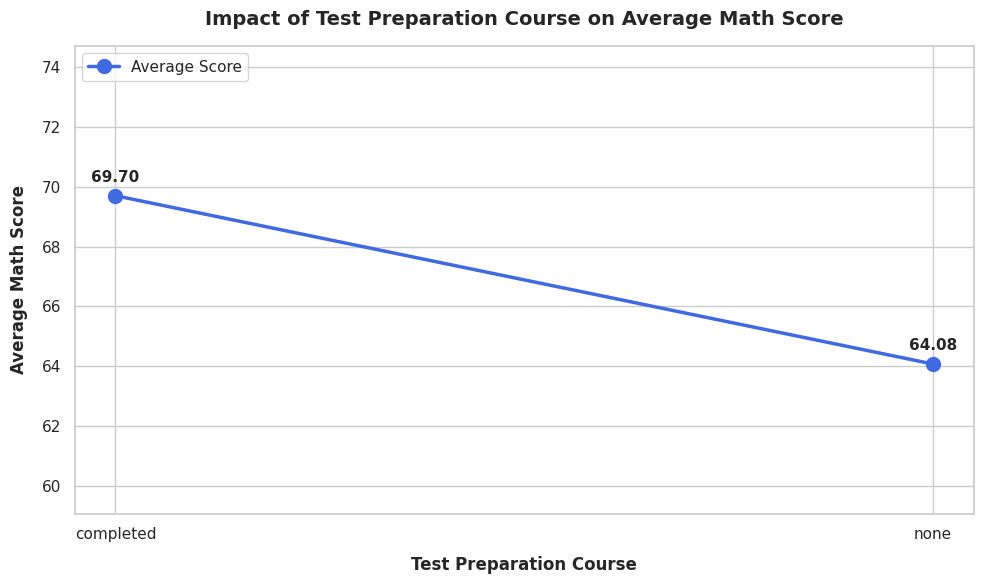

In [23]:
# Assuming df is already defined
avg_math_score_by_prep = df.groupby("test preparation course")["math score"].mean()

# Set a professional plotting style and context
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a customized line plot with markers and styling
plt.plot(avg_math_score_by_prep.index, avg_math_score_by_prep.values,
         color="royalblue", marker="o", markersize=10,
         linewidth=2.5, linestyle="-", label="Average Score")

# Customize axes labels and title
plt.xlabel("Test Preparation Course", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Average Math Score", fontsize=12, fontweight='bold', labelpad=10)
plt.title("Impact of Test Preparation Course on Average Math Score",
          fontsize=14, fontweight='bold', pad=15)

# Add value annotations to the data points
for x, y in zip(avg_math_score_by_prep.index, avg_math_score_by_prep.values):
    plt.annotate(f'{y:.2f}',
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=11,
                 fontweight='bold')

# Clean up the plot layout
plt.ylim(bottom=min(avg_math_score_by_prep.values) - 5,
         top=max(avg_math_score_by_prep.values) + 5)
plt.legend(loc="upper left")
plt.tight_layout()

# Display the plot
plt.show()

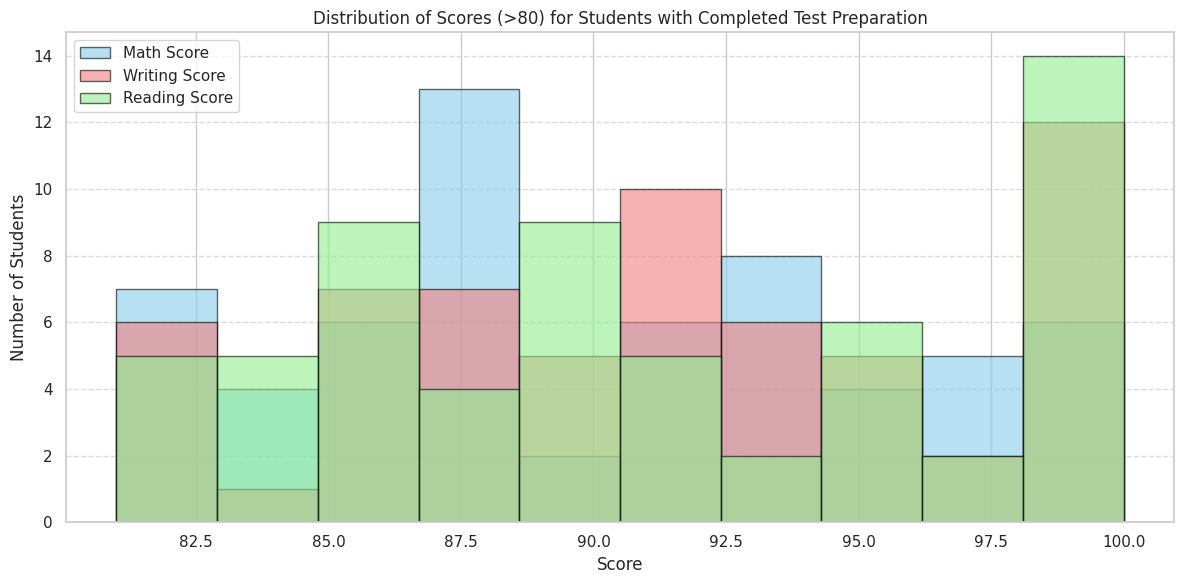

In [24]:
## Creating the histogram of the grades for students having more than 80 in math score, writing score, reading score and test preparation is completed

df_filtered = df[(df["math score"] > 80) & (df["writing score"] > 80) & (df["reading score"] > 80) & (df["test preparation course"] == "completed")]

plt.figure(figsize=(12, 6))
plt.hist(df_filtered["math score"], bins=10, color="skyblue", edgecolor="black", alpha=0.6, label="Math Score")
plt.hist(df_filtered["writing score"], bins=10, color="lightcoral", edgecolor="black", alpha=0.6, label="Writing Score")
plt.hist(df_filtered["reading score"], bins=10, color="lightgreen", edgecolor="black", alpha=0.6, label="Reading Score")

plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Scores (>80) for Students with Completed Test Preparation")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [26]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [28]:
df.shape

(1000, 8)

In [29]:
## Making Data ready to feed the ML model

## 1. Map the colunms to the numbers one by one

df["gender"] = df["gender"].map({"male": 0, "female": 1})
df["race/ethnicity"] = df["race/ethnicity"].map({"group A": 0, "group B": 1, "group C": 2, "group D": 3, "group E": 4})
df["parental level of education"] = df["parental level of education"].map({"some high school": 0, "high school": 1, "some college": 2, "associate's degree" : 3, "bachelor's degree": 4, "master's degree": 5})
df["lunch"] = df["lunch"].map({"standard": 0, "free/reduced": 1})
df["test preparation course"] = df["test preparation course"].map({"none" : 0, "completed" : 1})


In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,1,1,4,0,0,72,72,74
1,1,2,2,0,1,69,90,88
2,1,1,5,0,0,90,95,93
3,0,0,3,1,0,47,57,44
4,0,2,2,0,0,76,78,75


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   int64
 1   race/ethnicity               1000 non-null   int64
 2   parental level of education  1000 non-null   int64
 3   lunch                        1000 non-null   int64
 4   test preparation course      1000 non-null   int64
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


In [32]:
## Train/Test Split

from sklearn.model_selection import train_test_split

X = df.drop("test preparation course", axis=1) # Features, excluding the target
y = df["test preparation course"] # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Added stratify for balanced classes

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of target in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of target in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (800, 7)
X_test shape: (200, 7)
y_train shape: (800,)
y_test shape: (200,)

Distribution of target in y_train:
test preparation course
0    0.6425
1    0.3575
Name: proportion, dtype: float64

Distribution of target in y_test:
test preparation course
0    0.64
1    0.36
Name: proportion, dtype: float64


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Identify numerical columns to scale (the score columns)
numerical_cols = ['math score', 'reading score', 'writing score']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train_scaled head:")
print(X_train_scaled.head())
print("\nX_test_scaled head:")
print(X_test_scaled.head())

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

X_train_scaled head:
     gender  race/ethnicity  parental level of education  lunch  math score  \
929       1               2                            0      1   -1.177581   
927       1               3                            1      1   -0.062323   
553       0               3                            2      1    0.724918   
954       1               2                            2      0   -0.259133   
740       0               3                            4      0    0.921728   

     reading score  writing score  
929      -0.919295      -1.130456  
927      -0.573337       0.190363  
553      -0.504146      -0.271924  
954      -0.019806       0.058281  
740       0.256960       0.256404  

X_test_scaled head:
     gender  race/ethnicity  parental level of education  lunch  math score  \
370       0               4                            2      0    1.184141   
723       0               2                            1      0   -1.046374   
118       1               3   

## Make a Prediction with User Input

Now, let's create a function to take user input, preprocess it, and predict whether a student will complete the test preparation course.

In [37]:
import numpy as np

def get_user_input_and_predict(model, scaler, numerical_cols):
    print("\nPlease provide the following information for a new student:")

    # Get gender input
    gender_map = {'male': 0, 'female': 1}
    gender_input = input(f"Gender ({'/'.join(gender_map.keys())}): ").lower()
    while gender_input not in gender_map:
        print("Invalid gender. Please choose from 'male' or 'female'.")
        gender_input = input(f"Gender ({'/'.join(gender_map.keys())}): ").lower()
    gender_val = gender_map[gender_input]

    # Get race/ethnicity input
    # Updated race_ethnicity_map keys to match .title() output and prompt
    race_ethnicity_map = {'Group A': 0, 'Group B': 1, 'Group C': 2, 'Group D': 3, 'Group E': 4}
    race_ethnicity_options = [key for key in race_ethnicity_map.keys()]
    race_ethnicity_input = input(f"Race/Ethnicity ({'/'.join(race_ethnicity_options)}): ").title()
    while race_ethnicity_input not in race_ethnicity_map:
        print(f"Invalid race/ethnicity. Please choose from {', '.join(race_ethnicity_options)}.")
        race_ethnicity_input = input(f"Race/Ethnicity ({'/'.join(race_ethnicity_options)}): ").title()
    race_ethnicity_val = race_ethnicity_map[race_ethnicity_input]

    # Get parental level of education input
    parental_education_map = {"some high school": 0, "high school": 1, "some college": 2, "associate's degree" : 3, "bachelor's degree": 4, "master's degree": 5}
    parental_education_input = input(f"Parental Level of Education ({'/'.join(parental_education_map.keys())}): ").lower()
    while parental_education_input not in parental_education_map:
        print("Invalid parental education. Please choose from the provided options.")
        parental_education_input = input(f"Parental Level of Education ({'/'.join(parental_education_map.keys())}): ").lower()
    parental_education_val = parental_education_map[parental_education_input]

    # Get lunch input
    lunch_map = {'standard': 0, 'free/reduced': 1}
    lunch_input = input(f"Lunch ({'/'.join(lunch_map.keys())}): ").lower()
    while lunch_input not in lunch_map:
        print("Invalid lunch type. Please choose from 'standard' or 'free/reduced'.")
        lunch_input = input(f"Lunch ({'/'.join(lunch_map.keys())}): ").lower()
    lunch_val = lunch_map[lunch_input]

    # Get numerical scores
    math_score = int(input("Math Score (0-100): "))
    reading_score = int(input("Reading Score (0-100): "))
    writing_score = int(input("Writing Score (0-100): "))

    # Create a DataFrame for the new input
    user_data = pd.DataFrame({
        'gender': [gender_val],
        'race/ethnicity': [race_ethnicity_val],
        'parental level of education': [parental_education_val],
        'lunch': [lunch_val],
        'math score': [math_score],
        'reading score': [reading_score],
        'writing score': [writing_score]
    })

    # Scale the numerical features of the user input
    user_data_scaled = user_data.copy()
    user_data_scaled[numerical_cols] = scaler.transform(user_data[numerical_cols])

    # Make prediction
    prediction = model.predict(user_data_scaled)

    if prediction[0] == 1:
        print("\nPrediction: This student is predicted to have COMPLETED the test preparation course.")
    else:
        print("\nPrediction: This student is predicted to have NOT COMPLETED the test preparation course.")

# Call the function to get user input and make a prediction
get_user_input_and_predict(model, scaler, numerical_cols)


Please provide the following information for a new student:
Gender (male/female): male
Race/Ethnicity (Group A/Group B/Group C/Group D/Group E): Group A
Parental Level of Education (some high school/high school/some college/associate's degree/bachelor's degree/master's degree): some high school
Lunch (standard/free/reduced): standard
Math Score (0-100): 78
Reading Score (0-100): 90
Writing Score (0-100): 92

Prediction: This student is predicted to have COMPLETED the test preparation course.
